# Experimental Data Acquisition and Analysis Pipeline

## Data Acquisition

All measurements were acquired using a sampling window of 1 s and a sampling rate of 10 MHz, corresponding to a total of 10 million samples per waveform.

To attenuate the fluorescence signal reaching the detector, a combination of neutral density (ND) filters was placed in front of the PMT:

- ND = 1.0, corresponding to a transmission of 10%
- ND = 0.5, corresponding to a transmission of 31.6%

The combined transmission is therefore:
$$
T = 10^{-1.0} \times 10^{-0.5} \approx 3.16\%
$$

A bandpass filter was also inserted in the detection path.



### Noise Reference Measurement

The PMT cover was removed and the PMT control voltage was set to 0 V while keeping the excitation laser blocked. Under this condition, a dataset was acquired and used as the noise reference for subsequent analysis.



### Background Measurement

The PMT control voltage was then increased to 0.59 V while keeping the excitation laser blocked. A second dataset was acquired and used as the background reference.



### Fluorescence Measurements

Fluorescence measurements were performed at two excitation powers:

1. 1.7 mW after the objective
   - Corresponding to approximately 100 mW after the PBS
   - Note that an additional ND = 1.1 filter was present in the excitation path.

2. 3.4 mW after the objective
   - Corresponding to approximately 200 mW after the PBS
   - The same excitation-path attenuation configuration was maintained.

For each excitation condition, a separate dataset was acquired using the same PMT gain setting and acquisition parameters.

---



### Data Analysis

For each dataset, the PMT waveform was processed using the photon-counting analysis pipeline implemented in this notebook.

The mean photon count obtained from the background measurement was subtracted from the photon count measured at each excitation power:

$$
N_{\mathrm{corr}}
=
N_{\mathrm{measured}}
-
N_{\mathrm{background}}
$$

where $(N_{\mathrm{corr}})$ is the background-corrected photon count.




### Power Dependence Analysis

The excitation-power dependence was analyzed using the background-corrected photon counts.

For each excitation condition:

$$
x = \log_{10}(P)
$$

$$
y = \log_{10}(N_{\mathrm{corr}})
$$

where $(P)$ is the excitation power after the objective and $(N_{\mathrm{corr}})$ is the background-corrected photon count.

A linear fit was then performed:

$$
\log_{10}(N_{\mathrm{corr}})
=
a\times \log_{10}(P)
+
b
$$

The fitted slope $(a)$ corresponds to the power-law dependence.


In [4]:
import csv
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.signal import find_peaks


In [5]:
# -----------------------------
# User-configurable parameters
# -----------------------------
# DAQ-specific loading is replaced here with oscilloscope .npz folders from
# data_scopecapture(notrigger).ipynb. Downstream analysis still consumes the
# same internal 1-D voltage waveform named "signal".
NOISE_DATA_FOLDER = "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/PMT_calibration/20260609_PMT_2Pverification/ND1.5/PMT=0v_laseroff/data"

DATA_FOLDERS = [
    "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/PMT_calibration/20260609_PMT_2Pverification/ND1.5/PMT=0.59v_laseroff/data",  # background
    "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/PMT_calibration/20260609_PMT_2Pverification/ND1.5/PMT=0.59v_1.7mw/data",
    "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/PMT_calibration/20260609_PMT_2Pverification/ND1.5/PMT=0.59v_3.4mw/data",
]

# Peak/minimum detection settings.
pulse_width = 200      # ns
PROMINENCE = 0.005

# Histogram settings used by the existing thresholding workflow.
HIST_BINS = 200
HIST_YMAX = 500


def load_signal(file):
    # Scope-compatible adapter: return the calibrated waveform in the same
    # 1-D internal representation used by the original DAQ workflow.
    with np.load(file) as data:
        return np.asarray(data["signal"]).reshape(-1)


def dataset_label(folder_path):
    folder = Path(folder_path)
    return folder.parent.name if folder.name == "data" else folder.name


def extract_power_mw(folder_path):
    match = re.search(r"([0-9]+(?:\.[0-9]+)?)\s*mw", dataset_label(folder_path), flags=re.IGNORECASE)
    return float(match.group(1)) if match else None


def is_background_dataset(folder_path):
    return extract_power_mw(folder_path) is None and "laseroff" in dataset_label(folder_path).lower()


def output_folder_for_dataset(folder_path):
    folder = Path(folder_path)
    return folder.parent if folder.name == "data" else folder


def count_photon_events(signal, threshold, distance):
    peaks, _ = find_peaks(
        -signal,
        prominence=PROMINENCE,
        distance=distance,
    )

    valid_peaks = peaks[signal[peaks] < threshold]

    return int(len(valid_peaks))


def analyze_dataset(folder_path):
    data_dir = Path(folder_path)
    output_dir = output_folder_for_dataset(folder_path)
    npz_files = sorted(data_dir.glob("*.npz"))

    if not npz_files:
        raise FileNotFoundError(f"No .npz files found in {data_dir}")

    with np.load(npz_files[0]) as example_data:
        sample_rate = float(example_data["sample_rate"])

    # Oscilloscope time-axis metadata is stored as sample_rate; convert it to the
    # sampling interval expected by the unchanged pulse-distance calculations.
    sampling_interval = 1e9 / sample_rate  # ns
    n_samples = math.ceil(pulse_width / sampling_interval)
    minima_distance = n_samples

    # Step 1: Load and summarize all signal samples.
    # Each .npz file stores one waveform in the "signal" array. The notebook
    # combines all waveform samples so the baseline/noise distribution can be
    # inspected across the full acquisition set.
    all_signal_chunks = []
    total_signal_samples = 0

    for file in npz_files:
        signal = load_signal(file)
        all_signal_chunks.append(signal)
        total_signal_samples += signal.size

    all_signal = np.concatenate(all_signal_chunks)
    signal_mean = float(np.mean(abs(all_signal)))
    signal_std = float(np.std(all_signal))
    signal_counts, signal_edges = np.histogram(all_signal, bins=HIST_BINS)

    # Step 2: Find local minima and build the pulse-height histogram.
    # The existing workflow is reused here: local minima are found by applying
    # scipy.signal.find_peaks to -signal, then the corresponding signal voltages
    # are collected across all files.
    all_minima_chunks = []

    for file in npz_files:
        signal = load_signal(file)

        peaks, properties = find_peaks(
            -signal,
            prominence=PROMINENCE,
            distance=minima_distance,
        )
        all_minima_chunks.append(signal[peaks])

    all_minima = np.concatenate(all_minima_chunks) if all_minima_chunks else np.array([])
    minima_counts, minima_edges = np.histogram(all_minima, bins=HIST_BINS)
    minima_centers = 0.5 * (minima_edges[:-1] + minima_edges[1:])

    # Step 3: Automatic threshold selection.
    # Local minima in the negative-voltage side of the minima histogram mark valleys
    # between pulse-height populations. A PMT=0 scope noise reference is used to reject
    # candidate thresholds that are still inside the mean absolute noise level.
    noise_data_dir = Path(NOISE_DATA_FOLDER)
    noise_files = sorted(noise_data_dir.glob("*.npz"))

    if not noise_files:
        raise FileNotFoundError(f"No .npz files found in noise reference folder: {noise_data_dir}")

    noise_signal_chunks = []
    for file in noise_files:
        noise_signal_chunks.append(load_signal(file))

    all_noise_signal = np.concatenate(noise_signal_chunks)
    noise_reference = np.min(all_noise_signal)

    negative_mask = minima_centers < 0
    negative_counts = minima_counts[negative_mask]
    negative_centers = minima_centers[negative_mask]

    hist_minima_indices, _ = find_peaks(-negative_counts, distance=1)
    hist_minima_voltages = negative_centers[hist_minima_indices]
    hist_minima_counts = negative_counts[hist_minima_indices]

    candidates = sorted(
        zip(hist_minima_voltages, hist_minima_counts),
        key=lambda item: item[0],
        reverse=True,
    )

    if candidates:
        threshold = None
        for voltage, count in candidates:
            if abs(voltage) > abs(noise_reference):
                threshold = float(voltage) - 5 * signal_std  # strict threshold
                # threshold = float(voltage)
                break

        if threshold is None:
            threshold = float(candidates[-1][0])
    else:
        threshold = float(np.max(all_minima[all_minima < 0]))

    # Step 4: Photon counting.
    # Count photons directly from detected pulse minima.
    # A photon event is defined as a local minimum whose voltage
    # is below the selected threshold.
    photon_counts = []

    for file in npz_files:
        signal = load_signal(file)

        photon_count = count_photon_events(
            signal,
            threshold,
            minima_distance,
        )

        photon_counts.append(
            {
                "filename": file.name,
                "photon_count": photon_count,
            }
        )

    photon_count_values = np.array(
        [row["photon_count"] for row in photon_counts]
    )

    # Step 5: Photon count summary.
    photon_summary_path = output_dir / "photon_count_summary.csv"

    with photon_summary_path.open("w", newline="") as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=[
                "filename",
                "photon_count",
            ],
        )
        writer.writeheader()
        writer.writerows(photon_counts)

    mean_photon_count = float(np.mean(photon_count_values))
    std_photon_count = float(np.std(photon_count_values))
    min_photon_count = int(np.min(photon_count_values))
    max_photon_count = int(np.max(photon_count_values))

    # Step 6: Final summary table.
    summary_rows = [
        {"Metric": "Number of files", "Value": len(npz_files)},
        {"Metric": "Total signal samples", "Value": total_signal_samples},
        {"Metric": "Absolute signal mean", "Value": signal_mean},
        {"Metric": "Signal std", "Value": signal_std},
        {"Metric": "Number of minima", "Value": len(all_minima)},
        {"Metric": "Threshold (V)", "Value": threshold},
        {"Metric": "Minimum photon count", "Value": min_photon_count},
        {"Metric": "Maximum photon count", "Value": max_photon_count},
        {"Metric": "Mean photon count", "Value": mean_photon_count},
        {"Metric": "Std photon count", "Value": std_photon_count},
    ]

    final_summary_path = output_dir / "final_summary.csv"

    with final_summary_path.open("w", newline="") as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=["Metric", "Value"],
        )
        writer.writeheader()
        writer.writerows(summary_rows)

    return {
        "folder": str(data_dir),
        "label": dataset_label(data_dir),
        "power_mw": extract_power_mw(data_dir),
        "is_background": is_background_dataset(data_dir),
        "threshold": threshold,
        "mean_photon_count": mean_photon_count,
        "std_photon_count": std_photon_count,
        "min_photon_count": min_photon_count,
        "max_photon_count": max_photon_count,
        "signal_mean": signal_mean,
        "signal_std": signal_std,
        "num_files": len(npz_files),
        "total_signal_samples": total_signal_samples,
        "num_minima": len(all_minima),
        "sample_rate": sample_rate,
        "sampling_interval": sampling_interval,
        "minima_distance": minima_distance,
        "noise_reference": float(noise_reference),
        "signal_histogram": (signal_counts, signal_edges),
        "minima_histogram": (minima_counts, minima_edges),
        "minima_histogram_centers": minima_centers,
        "histogram_threshold_candidates": candidates,
        "photon_counts": photon_counts,
        "photon_count_values": photon_count_values,
        "summary_rows": summary_rows,
        "photon_summary_path": photon_summary_path,
        "final_summary_path": final_summary_path,
    }


#### Data inspection

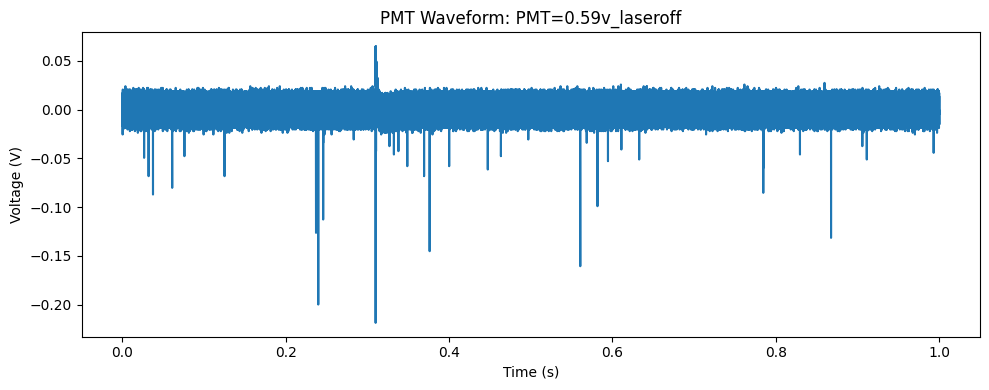

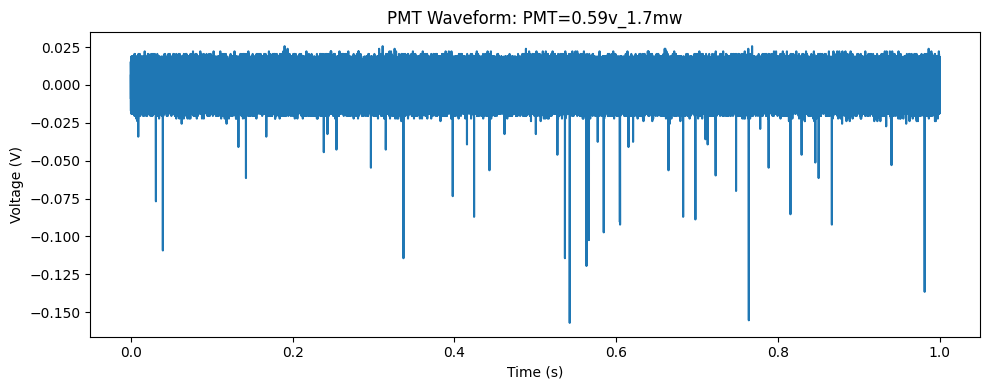

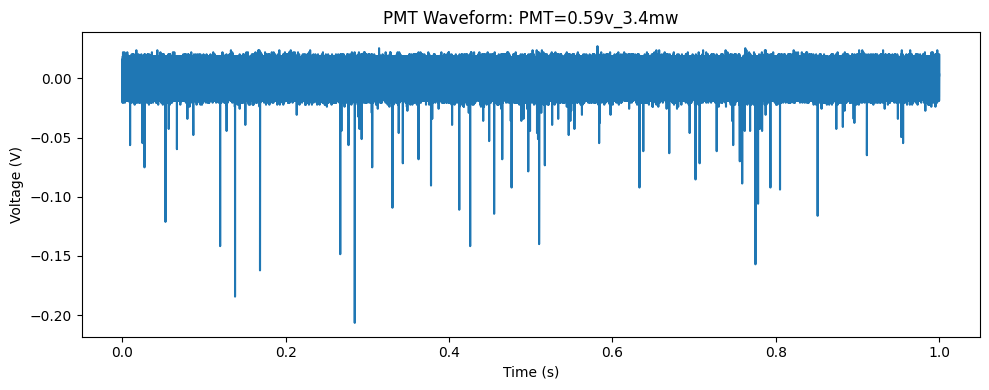

In [6]:
for folder_path in DATA_FOLDERS:
    data_dir = Path(folder_path)
    npz_files = sorted(data_dir.glob("*.npz"))

    if not npz_files:
        raise FileNotFoundError(f"No .npz files found in {data_dir}")

    file = npz_files[1]

    with np.load(file) as data:
        signal = data["signal"]
        sample_rate = float(data["sample_rate"])

    time = np.arange(len(signal)) / sample_rate

    plt.figure(figsize=(10, 4))
    plt.plot(time, signal)
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.title(f"PMT Waveform: {dataset_label(folder_path)}")
    plt.tight_layout()
    plt.show()


In [7]:
def print_final_metrics(result):
    print("=" * 50)
    print(f"Dataset: {result['label']}")
    print("=" * 50)
    print(f"Number of files: {result['num_files']}")
    print(f"Total signal samples: {result['total_signal_samples']}")
    print(f"Absolute signal mean: {result['signal_mean']:.8g}")
    print(f"Signal std: {result['signal_std']:.8g}")
    print(f"Number of minima: {result['num_minima']}")
    print(f"Threshold (V): {result['threshold']:.8g}")
    print(f"Minimum photon count: {result['min_photon_count']}")
    print(f"Maximum photon count: {result['max_photon_count']}")
    print(f"Mean photon count: {result['mean_photon_count']:.8g}")
    print(f"Std photon count: {result['std_photon_count']:.8g}")
    print()

results = []
for folder_path in DATA_FOLDERS:
    result = analyze_dataset(folder_path)
    results.append(result)
    print_final_metrics(result)


Dataset: PMT=0.59v_laseroff
Number of files: 10
Total signal samples: 100000000
Absolute signal mean: 0.0041477467
Signal std: 0.005246935
Number of minima: 23334701
Threshold (V): -0.052705978
Minimum photon count: 6
Maximum photon count: 20
Mean photon count: 14.8
Std photon count: 5.2687759

Dataset: PMT=0.59v_1.7mw
Number of files: 10
Total signal samples: 100000000
Absolute signal mean: 0.0041324127
Signal std: 0.005218372
Number of minima: 23325205
Threshold (V): -0.052742397
Minimum photon count: 19
Maximum photon count: 32
Mean photon count: 25.1
Std photon count: 4.592385

Dataset: PMT=0.59v_3.4mw
Number of files: 10
Total signal samples: 100000000
Absolute signal mean: 0.0041396041
Signal std: 0.0052293175
Number of minima: 23332310
Threshold (V): -0.052536808
Minimum photon count: 42
Maximum photon count: 70
Mean photon count: 55.4
Std photon count: 7.4859869



In [8]:
background_results = [result for result in results if result["is_background"]]

if not background_results:
    raise ValueError("No background dataset found. Expected a DATA_FOLDERS entry such as PMT=0.59v_laseroff.")

background_result = background_results[0]
background_photon_count = background_result["mean_photon_count"]

power_rows = []
for result in results:
    power = result["power_mw"]
    if power is None:
        continue

    corrected_count = result["mean_photon_count"] - background_photon_count
    power_rows.append(
        {
            "Power (mW)": power,
            "Mean Photon Count": result["mean_photon_count"],
            "Corrected Photon Count": corrected_count,
        }
    )

power_table = "| Power (mW) | Mean Photon Count | Photon Count - Background |\n|---:|---:|---:|\n" + "\n".join(
    f"| {row['Power (mW)']:.8g} | {row['Mean Photon Count']:.8g} | {row['Corrected Photon Count']:.8g} |"
    for row in power_rows
)
display(Markdown(power_table))


| Power (mW) | Mean Photon Count | Photon Count - Background |
|---:|---:|---:|
| 1.7 | 25.1 | 10.3 |
| 3.4 | 55.4 | 40.6 |

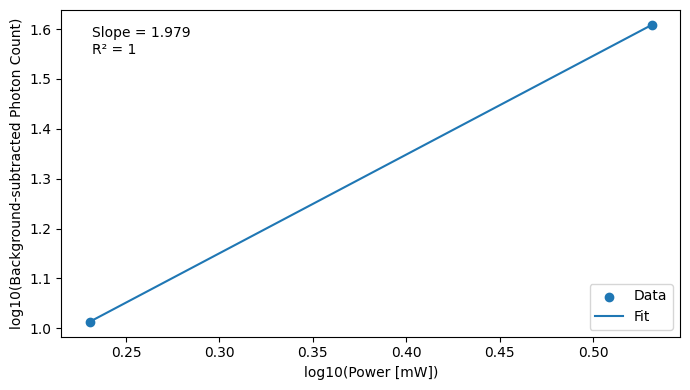

Power-law fit:
Log (Photon Count) ∝ 1.9788354 * Log(Power)
Slope = 1.9788354
R² = 1


In [9]:
power_values = np.array([row["Power (mW)"] for row in power_rows], dtype=float)
corrected_counts = np.array([row["Corrected Photon Count"] for row in power_rows], dtype=float)

fit_mask = (power_values > 0) & (corrected_counts > 0)
fit_power = power_values[fit_mask]
fit_counts = corrected_counts[fit_mask]

if fit_power.size < 2:
    raise ValueError("At least two datasets with power > 0 and corrected_count > 0 are required for the log-log fit.")

log_power = np.log10(fit_power)
log_count = np.log10(fit_counts)

slope, intercept = np.polyfit(log_power, log_count, 1)
fitted_log_count = slope * log_power + intercept
ss_res = np.sum((log_count - fitted_log_count) ** 2)
ss_tot = np.sum((log_count - np.mean(log_count)) ** 2)
r_squared = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

fit_x = np.linspace(log_power.min(), log_power.max(), 100)
fit_y = slope * fit_x + intercept

plt.figure(figsize=(7, 4))
plt.scatter(log_power, log_count, label="Data")
plt.plot(fit_x, fit_y, label="Fit")
plt.xlabel("log10(Power [mW])")
plt.ylabel("log10(Background-subtracted Photon Count)")
plt.text(
    0.05,
    0.95,
    f"Slope = {slope:.4g}\nR² = {r_squared:.4g}",
    transform=plt.gca().transAxes,
    va="top",
)
plt.legend()
plt.tight_layout()
plt.show()

print("Power-law fit:")
print(f"Log (Photon Count) ∝ {slope:.8g} * Log(Power)")
print(f"Slope = {slope:.8g}")
print(f"R² = {r_squared:.8g}")
